<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🔬 Clustering Avanzado</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 3 — Más allá de K-Means: límites del algoritmo, DBSCAN, selección objetiva de k, clustering jerárquico y reducción de dimensionalidad</p>
</div>

En `2-introduccion-machine-learning.ipynb` se introdujo el clustering con K-Means sobre datos sintéticos generados con `make_blobs`: grupos esféricos, bien separados y de tamaño similar — la situación más favorable posible para este algoritmo. Ese ejemplo alcanza para entender el mecanismo básico de K-Means, pero no para ver qué ocurre cuando sus suposiciones no se cumplen, ni para responder una pregunta que en la práctica rara vez tiene una respuesta obvia: ¿cuántos clústeres hay realmente en los datos?

Este notebook retoma el clustering desde ese punto. Primero, con datos sintéticos (`make_moons` y `make_circles`) se muestran los límites de K-Means ante formas no convexas, y cómo DBSCAN los resuelve al agrupar por densidad en lugar de por distancia a un centroide. Luego, con el dataset **Wine** de scikit-learn, se aborda un caso más realista: 13 variables (imposibles de graficar directamente), sin usar las etiquetas reales durante el clustering, se busca un número de clústeres de forma objetiva, se compara K-Means contra clustering jerárquico, se usa PCA únicamente para poder visualizar el resultado, y — solo al final, con fines didácticos — se compara lo encontrado contra la etiqueta real que Wine sí incluye.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#limites-kmeans">Límites de K-Means ante formas no convexas</a></li>
<li><a href="#dbscan">DBSCAN: clustering basado en densidad</a></li>
<li><a href="#elegir-k">Elegir k de forma objetiva (dataset Wine)</a></li>
<li><a href="#jerarquico">Clustering jerárquico y dendrograma</a></li>
<li><a href="#pca-visualizacion">Reducción de dimensionalidad para visualizar</a></li>
<li><a href="#comparacion-real">Comparación final con las etiquetas reales</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="limites-kmeans"></a>

## <span style="color:#F97066;">Límites de K-Means ante formas no convexas</span>

K-Means asigna cada punto al centroide más cercano, lo que equivalente a dividir el espacio en regiones convexas (celdas de Voronoi). Esta estrategia funciona bien cuando los clústeres reales son aproximadamente esféricos, pero falla cuando tienen formas alargadas, anidadas o entrelazadas — sin importar cuántas veces se reinicialice el algoritmo o cuántas iteraciones se le permitan.

Para verlo, se generan dos conjuntos de datos sintéticos en 2D cuya estructura es evidente a simple vista, pero no es esférica:

- `make_moons`: dos "medias lunas" entrelazadas.
- `make_circles`: un círculo interior rodeado de un anillo exterior.

En ambos casos, el número de grupos visibles es 2, por lo que se ajusta K-Means con k=2.

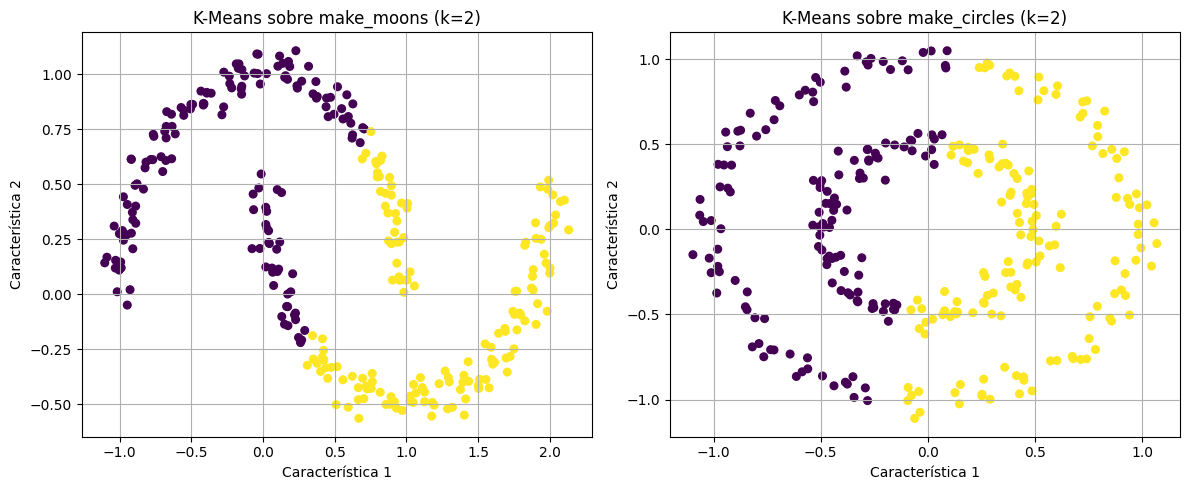

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import KMeans

# 1. Generar datos sintéticos con formas no convexas
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.05, random_state=42)
X_circles, y_circles_true = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# 2. Aplicar K-Means (k=2) a cada conjunto
kmeans_moons = KMeans(n_clusters=2, n_init="auto", random_state=42).fit_predict(X_moons)
kmeans_circles = KMeans(n_clusters=2, n_init="auto", random_state=42).fit_predict(X_circles)

# 3. Visualizar resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moons, cmap="viridis", s=30)
axes[0].set_title("K-Means sobre make_moons (k=2)")
axes[0].set_xlabel("Característica 1")
axes[0].set_ylabel("Característica 2")
axes[0].grid(True)

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=kmeans_circles, cmap="viridis", s=30)
axes[1].set_title("K-Means sobre make_circles (k=2)")
axes[1].set_xlabel("Característica 1")
axes[1].set_ylabel("Característica 2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

En ambos casos, K-Means traza una frontera aproximadamente recta entre los dos centroides, que corta cada media luna y cada círculo por la mitad en lugar de respetar su forma real. El algoritmo no está "equivocado": simplemente está haciendo exactamente lo que fue diseñado para hacer (minimizar la distancia de cada punto a su centroide), pero ese criterio no captura la estructura de datos con formas no convexas.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Este resultado no depende de la inicialización ni del número de iteraciones: es una consecuencia directa de que K-Means solo puede producir fronteras de decisión convexas (celdas de Voronoi alrededor de cada centroide). Ninguna variante de sus hiperparámetros resuelve el problema — se necesita un algoritmo con un criterio de agrupamiento distinto, como se ve a continuación.
</div>

<a id="dbscan"></a>

## <span style="color:#F97066;">DBSCAN: clustering basado en densidad</span>

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) agrupa los puntos según qué tan densamente conectados están entre sí, en lugar de qué tan cerca están de un centroide. Su idea central:

- Un punto es un **punto núcleo** si tiene al menos `min_samples` vecinos dentro de un radio `eps`.
- Los clústeres se forman conectando puntos núcleo cercanos entre sí (y los puntos que caen en su vecindad).
- Los puntos que no pertenecen a ningún clúster se marcan como **ruido** (etiqueta `-1`), en lugar de forzarlos a pertenecer a un grupo.

Como no asume ninguna forma geométrica particular para los clústeres, DBSCAN puede seguir estructuras alargadas o anidadas como las de `make_moons` y `make_circles`. A cambio, requiere ajustar `eps` y `min_samples`: un `eps` demasiado pequeño fragmenta los datos en muchos clústeres diminutos y mucho ruido; uno demasiado grande termina fusionando todo en un único clúster.

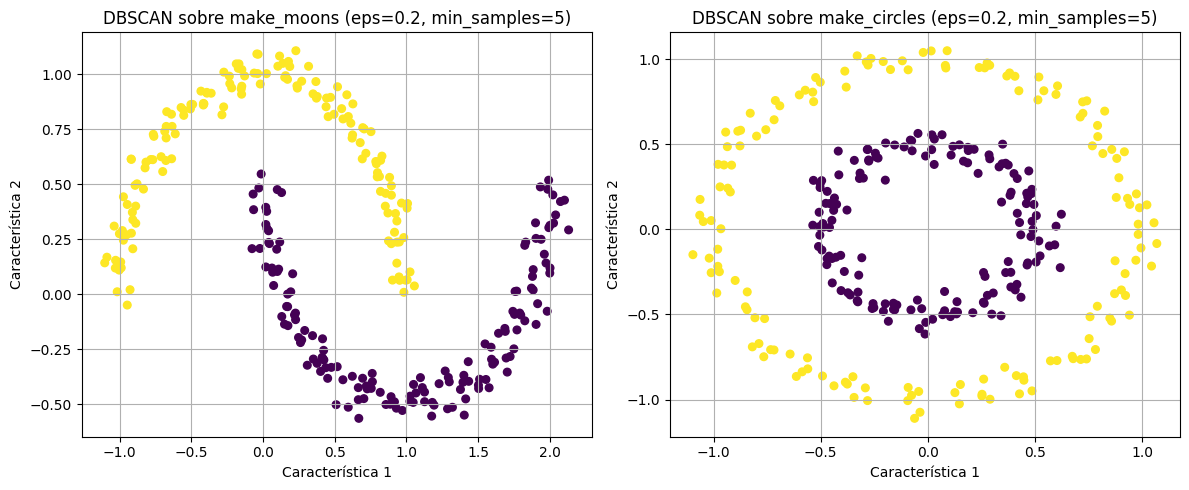

In [2]:
from sklearn.cluster import DBSCAN

# 1. Aplicar DBSCAN a los mismos datos, ajustando eps y min_samples
dbscan_moons = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moons)
dbscan_circles = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_circles)

# 2. Visualizar resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_moons, cmap="viridis", s=30)
axes[0].set_title("DBSCAN sobre make_moons (eps=0.2, min_samples=5)")
axes[0].set_xlabel("Característica 1")
axes[0].set_ylabel("Característica 2")
axes[0].grid(True)

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=dbscan_circles, cmap="viridis", s=30)
axes[1].set_title("DBSCAN sobre make_circles (eps=0.2, min_samples=5)")
axes[1].set_xlabel("Característica 1")
axes[1].set_ylabel("Característica 2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Modifique el valor de `eps` en la celda anterior (por ejemplo, a 0.1 o a 0.3) y observe cómo cambia el resultado. ¿En qué punto DBSCAN empieza a marcar puntos como ruido (etiqueta `-1`)? ¿En qué punto termina fusionando ambos grupos en uno solo?

In [3]:
from sklearn.metrics import adjusted_rand_score

# 1. Cuantificar objetivamente qué tan bien recupera cada algoritmo la estructura real
# (make_moons y make_circles devuelven la etiqueta "verdadera" de cada punto, usada aquí solo para validar)
resumen_ari = {
    "K-Means (moons)": adjusted_rand_score(y_moons_true, kmeans_moons),
    "DBSCAN (moons)": adjusted_rand_score(y_moons_true, dbscan_moons),
    "K-Means (circles)": adjusted_rand_score(y_circles_true, kmeans_circles),
    "DBSCAN (circles)": adjusted_rand_score(y_circles_true, dbscan_circles),
}

for nombre, valor in resumen_ari.items():
    print(f"{nombre}: Adjusted Rand Index = {valor:.3f}")

K-Means (moons): Adjusted Rand Index = 0.247
DBSCAN (moons): Adjusted Rand Index = 1.000
K-Means (circles): Adjusted Rand Index = -0.003
DBSCAN (circles): Adjusted Rand Index = 1.000


El Adjusted Rand Index (ARI) compara la partición encontrada por el algoritmo contra la partición real (aquí conocida porque los datos son sintéticos), con 1.0 como coincidencia perfecta y valores cercanos a 0 equivalentes a una asignación aleatoria. Los resultados confirman lo observado visualmente: DBSCAN recupera exactamente la estructura de ambos conjuntos, mientras que K-Means, atado a fronteras convexas, obtiene un ARI notablemente más bajo — para `make_circles` en particular, prácticamente equivalente a una asignación al azar, ya que el círculo interior y el anillo exterior comparten el mismo centro y K-Means no tiene forma de separarlos por distancia a un centroide.

<a id="elegir-k"></a>

## <span style="color:#F97066;">Elegir k de forma objetiva</span>

Tanto K-Means como el clustering jerárquico (visto en la siguiente sección) requieren decidir de antemano cuántos clústeres buscar. En los ejemplos anteriores esa decisión fue trivial porque los datos eran sintéticos y de solo 2 variables, visibles a simple vista. En un problema real rara vez se tiene ese lujo.

Para explorar esto se usa el dataset **Wine** de scikit-learn (`load_wine`), en lugar de Iris:

<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.9em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Dataset</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Variables</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Clases</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Separabilidad</th>
</tr>
</thead>
<tbody>
<tr style="background:rgba(14,165,233,0.07);"><td style="padding:6px 14px;">Iris</td><td style="padding:6px 14px;">4</td><td style="padding:6px 14px;">3</td><td style="padding:6px 14px;">Muy alta (casi linealmente separables)</td></tr>
<tr><td style="padding:6px 14px;">Wine</td><td style="padding:6px 14px;">13</td><td style="padding:6px 14px;">3</td><td style="padding:6px 14px;">Moderada (clases con solapamiento parcial)</td></tr>
</tbody>
</table>
</div>

Con 13 variables, Wine no se puede graficar directamente (a diferencia de los datos sintéticos anteriores), lo que justifica el uso de PCA más adelante solo para visualizar. Y como sus tres cultivares no están tan perfectamente separados como las especies de Iris, el resultado del clustering no es trivialmente "perfecto", lo que permite discutir con más sentido qué tan bien (o mal) coincide un clustering no supervisado con una estructura real.

Como en todo problema de clustering, las etiquetas reales (el cultivar de cada muestra) se ignoran deliberadamente durante todo el proceso — solo se usarán al final, a modo de validación.

In [4]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# 1. Cargar datos (la etiqueta real se guarda aparte y no se usa todavía)
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# 2. Estandarizar variables (imprescindible: las escalas de las variables de Wine son muy distintas entre sí)
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

X_wine.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


<span style="color:#F97066;">1.</span> Método del codo y Silhouette Score

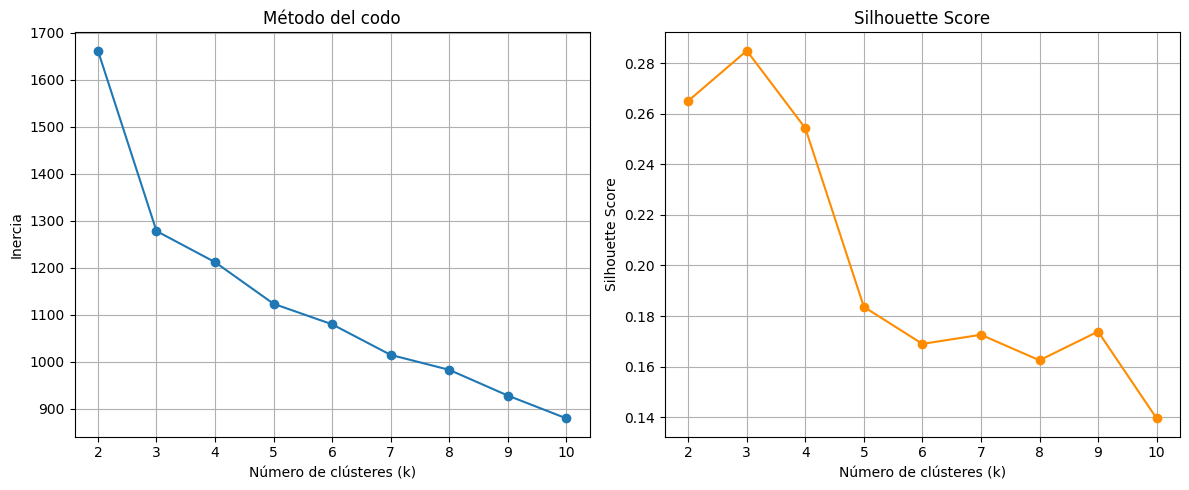

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Calcular inercia y silhouette score para varios valores de k
rango_k = range(2, 11)
inercias = []
sil_scores = []

for k in rango_k:
    modelo_k = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels_k = modelo_k.fit_predict(X_wine_scaled)
    inercias.append(modelo_k.inertia_)
    sil_scores.append(silhouette_score(X_wine_scaled, labels_k))

# 2. Visualizar método del codo y silhouette score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(rango_k), inercias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clústeres (k)")
axes[0].set_ylabel("Inercia")
axes[0].grid(True)

axes[1].plot(list(rango_k), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clústeres (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# 3. Identificar el k con mejor Silhouette Score
mejor_k = list(rango_k)[int(np.argmax(sil_scores))]
print(f"k con mayor Silhouette Score: {mejor_k}")
print(f"Silhouette Score correspondiente: {max(sil_scores):.3f}")

k con mayor Silhouette Score: 3
Silhouette Score correspondiente: 0.285


Los dos criterios se complementan pero no siempre coinciden con precisión. La inercia decrece de forma monótona a medida que aumenta k (siempre baja al agregar más clústeres, incluso cuando eso no aporta información real), por lo que el método del codo requiere buscar visualmente un punto donde la curva deja de descender bruscamente — un juicio hasta cierto punto subjetivo. El Silhouette Score, en cambio, entrega un valor objetivo y comparable directamente entre valores de k, por lo que resulta más práctico para automatizar la elección: en este caso, alcanza su máximo en <code>k=3</code>, el mismo número de cultivares que el dataset Wine documenta oficialmente — aunque, como se insiste en toda esta sección, esa etiqueta no se usó en ningún momento para llegar a esta conclusión.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Que el Silhouette Score coincida con el número real de clases es una buena señal, pero no una garantía general: en datasets sin una estructura de grupos tan marcada, ambos criterios pueden ser ambiguos o incluso contradecirse entre sí. Ante esa ambigüedad, suele ser razonable combinar el criterio cuantitativo con conocimiento del dominio del problema.
</div>

<a id="jerarquico"></a>

## <span style="color:#F97066;">Clustering jerárquico</span>

El clustering jerárquico aglomerativo construye los clústeres de abajo hacia arriba: comienza tratando cada punto como su propio clúster y, en cada paso, fusiona los dos clústeres más cercanos entre sí, hasta llegar a un único clúster que contiene todos los puntos. El resultado de este proceso se puede representar completo en un **dendrograma**, sin necesidad de fijar k de antemano — k se elige después, cortando el dendrograma a la altura deseada.

A diferencia de K-Means, el clustering jerárquico no depende de una inicialización aleatoria (el resultado es siempre el mismo para un mismo criterio de enlace) y permite inspeccionar visualmente distintos niveles de granularidad de los clústeres antes de decidir cuántos usar.

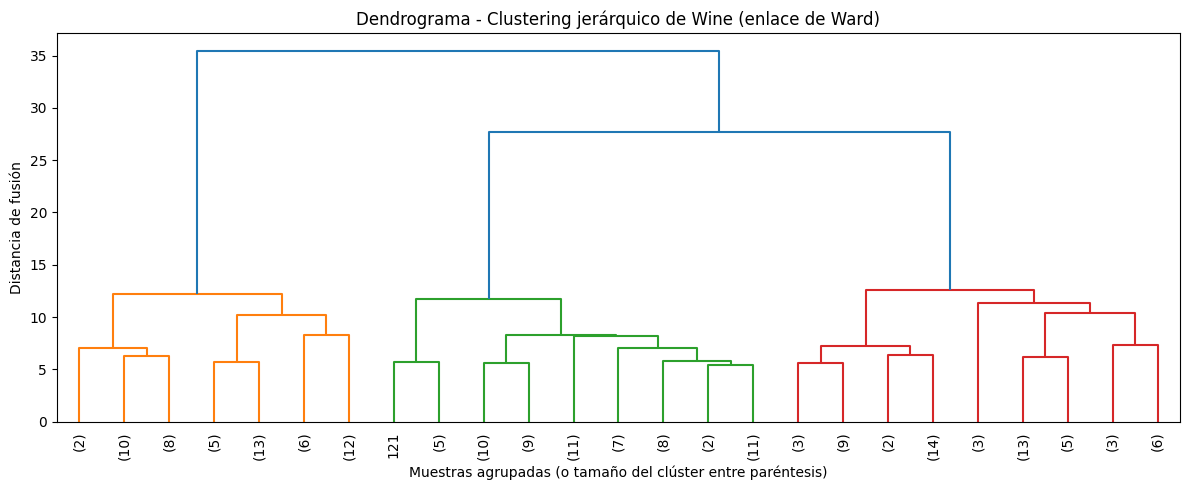

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Calcular la matriz de enlaces (linkage) con el método de Ward,
# que minimiza el incremento de varianza dentro de cada clúster al fusionar
Z = linkage(X_wine_scaled, method="ward")

# 2. Visualizar el dendrograma
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90.0)
plt.title("Dendrograma - Clustering jerárquico de Wine (enlace de Ward)")
plt.xlabel("Muestras agrupadas (o tamaño del clúster entre paréntesis)")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.show()

Las fusiones más altas del dendrograma (las últimas en ocurrir, de arriba hacia abajo) representan uniones entre grupos ya bastante distintos entre sí. Cortando el dendrograma en tres ramas principales —de forma consistente con el Silhouette Score obtenido en la sección anterior— se obtiene una partición en <code>k=3</code> clústeres.

In [8]:
# 3. Aplicar Agglomerative Clustering con k=3 (consistente con el Silhouette Score de la sección anterior)
modelo_jerarquico = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_jerarquico = modelo_jerarquico.fit_predict(X_wine_scaled)

print("Tamaño de cada clúster jerárquico:", np.bincount(labels_jerarquico))

Tamaño de cada clúster jerárquico: [58 56 64]


<a id="pca-visualizacion"></a>

## <span style="color:#F97066;">Reducción de dimensionalidad para visualizar</span>

El clustering de las dos secciones anteriores (K-Means con `mejor_k` y clustering jerárquico) se calculó completo sobre las 13 variables estandarizadas de Wine — no hay forma de graficar directamente un espacio de 13 dimensiones. Para poder inspeccionar visualmente los grupos encontrados, se proyectan esas mismas 13 variables a 2 componentes principales (PCA) **únicamente con fines de visualización**: el algoritmo de clustering no se vuelve a ejecutar sobre estas 2 componentes, solo se usan para dibujar en un plano las asignaciones ya calculadas.

In [9]:
from sklearn.decomposition import PCA

# 1. Ajustar K-Means final con el k elegido en la sección anterior (sobre las 13 variables originales)
modelo_kmeans_final = KMeans(n_clusters=mejor_k, n_init="auto", random_state=42)
labels_kmeans_final = modelo_kmeans_final.fit_predict(X_wine_scaled)

# 2. Reducir a 2 componentes principales solo para visualizar (no para clusterizar)
pca = PCA(n_components=2, random_state=42)
X_wine_pca = pca.fit_transform(X_wine_scaled)

print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Varianza explicada total (2 componentes): {pca.explained_variance_ratio_.sum():.3f}")

Varianza explicada por cada componente: [0.36198848 0.1920749 ]
Varianza explicada total (2 componentes): 0.554


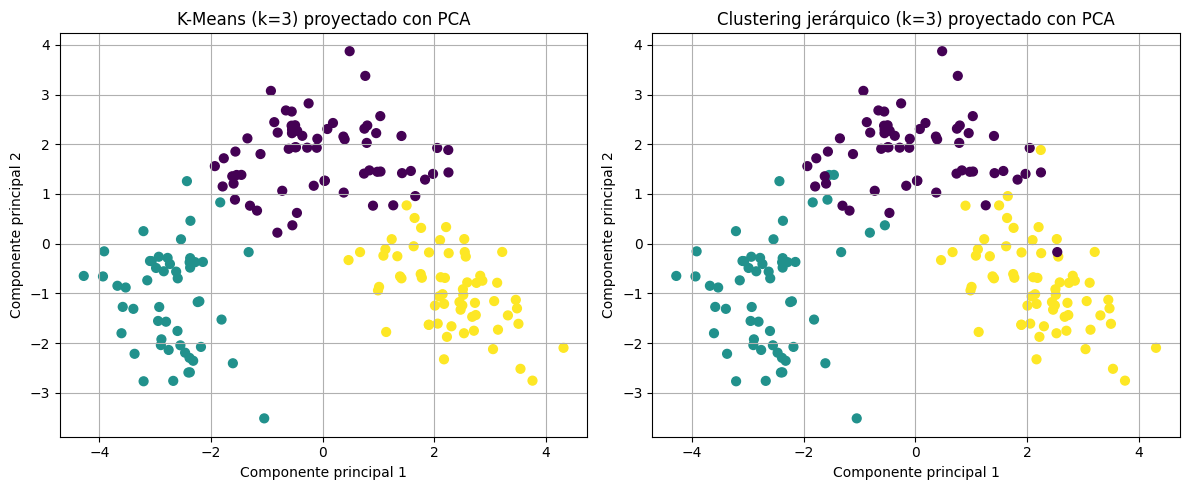

In [10]:
# 3. Visualizar clústeres de K-Means y de clustering jerárquico proyectados en 2D
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=labels_kmeans_final, cmap="viridis", s=40)
axes[0].set_title(f"K-Means (k={mejor_k}) proyectado con PCA")
axes[0].set_xlabel("Componente principal 1")
axes[0].set_ylabel("Componente principal 2")
axes[0].grid(True)

axes[1].scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=labels_jerarquico, cmap="viridis", s=40)
axes[1].set_title("Clustering jerárquico (k=3) proyectado con PCA")
axes[1].set_xlabel("Componente principal 1")
axes[1].set_ylabel("Componente principal 2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Las dos primeras componentes principales explican solo una fracción de la varianza total de las 13 variables originales (impresa en la celda anterior), por lo que esta proyección es una simplificación: dos puntos pueden verse cercanos en el plano y, sin embargo, estar más separados en el espacio de 13 dimensiones en el que realmente se calculó el clustering — o viceversa. Aun con esa limitación, la proyección permite confirmar visualmente que ambos algoritmos encuentran una estructura de tres grupos razonablemente compacta y separable, y que sus resultados son, en líneas generales, similares entre sí.

<a id="comparacion-real"></a>

## <span style="color:#F97066;">Comparación final con las etiquetas reales</span>

Wine incluye, además de las 13 variables químicas, una etiqueta real: el cultivar de uva del que proviene cada muestra (3 posibles valores). Esa etiqueta se ignoró deliberadamente durante todo el proceso de clustering anterior — ni la estandarización, ni el método del codo, ni el Silhouette Score, ni el ajuste de K-Means o del clustering jerárquico la usaron en ningún momento.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Esta comparación contra una etiqueta real solo es posible aquí porque Wine, como dataset de referencia, incluye esa etiqueta con fines didácticos. En un problema de clustering real casi nunca se dispone de ella — si se dispusiera, probablemente se abordaría el problema como clasificación supervisada en lugar de clustering. Esta sección es entonces una validación posterior, no un paso más del flujo de trabajo de clustering en sí.
</div>

In [11]:
from sklearn.metrics import adjusted_rand_score

# 1. Comparar K-Means y clustering jerárquico contra las etiquetas reales (cultivar)
ari_kmeans = adjusted_rand_score(wine.target, labels_kmeans_final)
ari_jerarquico = adjusted_rand_score(wine.target, labels_jerarquico)

print(f"Adjusted Rand Index (K-Means vs. etiqueta real): {ari_kmeans:.3f}")
print(f"Adjusted Rand Index (jerárquico vs. etiqueta real): {ari_jerarquico:.3f}")

Adjusted Rand Index (K-Means vs. etiqueta real): 0.897
Adjusted Rand Index (jerárquico vs. etiqueta real): 0.790


<span style="color:#F97066;">2.</span> Tabla de contingencia (cultivar real vs. clúster encontrado)

In [12]:
# 2. Tabla de contingencia: K-Means
tabla_kmeans = pd.crosstab(
    wine.target, labels_kmeans_final,
    rownames=["Cultivar real"], colnames=["Clúster K-Means"],
)
tabla_kmeans

Clúster K-Means,0,1,2
Cultivar real,,,
0,0,0,59
1,65,3,3
2,0,48,0


In [13]:
# 3. Tabla de contingencia: clustering jerárquico
tabla_jerarquico = pd.crosstab(
    wine.target, labels_jerarquico,
    rownames=["Cultivar real"], colnames=["Clúster jerárquico"],
)
tabla_jerarquico

Clúster jerárquico,0,1,2
Cultivar real,,,
0,0,0,59
1,58,8,5
2,0,48,0


Ambos algoritmos obtienen un Adjusted Rand Index alto (bien por encima de 0, que correspondería a una asignación al azar), lo que indica que la estructura de tres grupos hallada de forma completamente no supervisada coincide en buena medida con los tres cultivares reales. Las tablas de contingencia muestran el mismo patrón para los dos algoritmos: el cultivar con 59 muestras y el cultivar con 48 muestras quedan cada uno casi perfectamente contenidos en un único clúster, mientras que el cultivar restante (71 muestras) se reparte principalmente en un clúster propio pero con algunas muestras mezcladas hacia los otros dos. Esto es consistente con lo señalado al elegir Wine sobre Iris al inicio: a diferencia de las especies de Iris, los cultivares de Wine no están perfectamente separados en el espacio de las 13 variables químicas, por lo que ni el mejor clustering no supervisado logra —ni debería esperarse que logre— una coincidencia perfecta con la etiqueta real.

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>

- K-Means asume clústeres aproximadamente esféricos: sobre `make_moons` y `make_circles` traza fronteras convexas que no respetan la forma real de los datos.
- DBSCAN agrupa por densidad en lugar de por distancia a un centroide, y recupera exactamente esas mismas formas no convexas, a costa de tener que ajustar `eps` y `min_samples`.
- Sobre el dataset Wine (estandarizado, sin usar la etiqueta real), el método del codo y, sobre todo, el Silhouette Score permiten elegir un número de clústeres de forma objetiva.
- El clustering jerárquico aglomerativo ofrece una alternativa a K-Means que no depende de una inicialización aleatoria, y que se puede inspeccionar visualmente mediante un dendrograma antes de fijar k.
- PCA permite visualizar en 2D un clustering calculado sobre 13 variables originales, sin que esa proyección reemplace el cálculo real del clustering.
- Comparar los clústeres encontrados contra la etiqueta real de cultivar (disponible en Wine solo con fines didácticos) confirmó que la estructura hallada de forma no supervisada coincide en buena medida con esa etiqueta, con las mismas ambigüedades que ya sugería la separabilidad moderada del dataset.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>5-modelos-ensamble.ipynb</code> — retoma el aprendizaje supervisado con bagging, boosting y técnicas de combinación de modelos (voting y stacking), profundizando lo visto en la sección de modelos de ensamble del notebook principal.</li>
</ul>
</div>